# 23 · Deep Learning for Time Series: LSTM and TCN

*Module 5 — Machine Learning in Finance*

The two most widely used deep architectures for sequential financial data, built from their defining equations up, trained honestly, and watched carefully for the exact moment they start memorizing instead of learning.

## 1. Motivation

Notebook 22 fed a tree ensemble a handful of hand-built features (5-day momentum, 20-day volatility, and so on) — summaries a person chose in advance. What if, instead, we gave a model the *raw* sequence of recent returns directly, and let it learn its own internal representation of what matters? This is the promise of deep learning applied to time series. It is also, as this notebook shows directly rather than just warns about, a promise that comes with a very real, very visible risk: a flexible enough network can learn to fit the *training* sequence's idiosyncrasies perfectly, while genuinely useful, generalizable structure remains just as hard to find as it always was.

## 2. Intuition

**LSTM (Long Short-Term Memory)** processes a sequence one step at a time, maintaining an internal "cell state" — a kind of running memory — that it can choose to write to, read from, or partially forget at every step, via a set of learned gates. This lets it in principle carry relevant information forward across long sequences without it automatically fading away, the core weakness of simpler recurrent architectures.

**TCN (Temporal Convolutional Network)** takes a completely different approach to the same problem: instead of processing one step at a time, it applies 1D convolutions across the whole sequence at once, using **causal** convolutions (a prediction at time $t$ only ever sees data up to $t$, never beyond) and **dilated** convolutions (each successive layer skips over exponentially more input positions), so that a stack of just a few layers can still have a very long effective "memory," or receptive field, while remaining fast to train in parallel — unlike an LSTM, which must process a sequence strictly step by step.

## 3. Theory

### 3.1 The LSTM cell, precisely

At each time step $t$, given the previous hidden state $h_{t-1}$, previous cell state $C_{t-1}$, and current input $x_t$:

$$
\begin{aligned}
f_t &= \sigma(W_f[h_{t-1}, x_t] + b_f) &&\text{(forget gate: what to discard from memory)}\\
i_t &= \sigma(W_i[h_{t-1}, x_t] + b_i) &&\text{(input gate: what new information to write)}\\
\tilde C_t &= \tanh(W_C[h_{t-1}, x_t] + b_C) &&\text{(candidate values to write)}\\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde C_t &&\text{(update the cell state)}\\
o_t &= \sigma(W_o[h_{t-1}, x_t] + b_o) &&\text{(output gate: what to reveal from memory)}\\
h_t &= o_t \odot \tanh(C_t) &&\text{(the new hidden state)}
\end{aligned}
$$

where $\sigma$ is the sigmoid function (outputs in $[0,1]$, acting as a soft "how much" gate) and $\odot$ is elementwise multiplication. The forget gate is the key mechanism enabling long-range memory: if $f_t\approx1$, the cell state passes through almost unchanged from one step to the next, letting information survive many steps without the vanishing-gradient decay that plagues a plain recurrent network.

### 3.2 The TCN block, precisely

A causal, dilated 1D convolution with dilation $d$ and kernel size $k$ computes, at position $t$:

$$
y_t = \sum_{j=0}^{k-1} w_j \, x_{t - j\cdot d} ,
$$

using only *past* inputs ($t, t-d, t-2d, \dots$) — the causal constraint, enforced in practice by padding the input on the left and trimming any output that would otherwise peek at future positions. Stacking $L$ such layers with dilation doubling each layer ($d=1,2,4,\dots,2^{L-1}$) gives a receptive field that grows *exponentially* with depth, $O(2^L)$, rather than linearly — a network can "see" far back in the sequence with only a handful of layers, all of which can be computed in parallel across the whole sequence at once (unlike an LSTM's inherently sequential processing).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(131)
_ = torch.manual_seed(0)

## 4. Implementation

### 4.1 Data: raw return sequences, not hand-built features

Same latent-state-driven return process as Notebook 22, for a fair comparison -- but this time the model receives the raw trailing 20-day return sequence directly, with no human-chosen summary statistics at all.

In [2]:
n = 2500
mom_state = np.zeros(n)
persistence, lam, idio_vol = 0.88, 0.010, 0.011
returns = np.zeros(n)
for t in range(n):
    mom_state[t] = persistence * (mom_state[t-1] if t > 0 else 0) + rng.normal(0, 0.25)
    returns[t] = lam * mom_state[t] + rng.normal(0, idio_vol)

L = 20   # sequence length fed to the network
X_seq, y_seq = [], []
for t in range(L, n - 1):
    X_seq.append(returns[t-L:t])
    y_seq.append(1.0 if returns[t] > 0 else 0.0)
X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)

EMBARGO = L
split = int(len(X_seq) * 0.7)
X_train, y_train = X_seq[:split - EMBARGO], y_seq[:split - EMBARGO]
X_test, y_test = X_seq[split:], y_seq[split:]

Xtr_t = torch.tensor(X_train).unsqueeze(-1)   # (batch, seq_len, 1 feature)
ytr_t = torch.tensor(y_train)
Xte_t = torch.tensor(X_test).unsqueeze(-1)
yte_t = torch.tensor(y_test)
print(f"Train: {Xtr_t.shape}   Test: {Xte_t.shape}")

Train: torch.Size([1715, 20, 1])   Test: torch.Size([744, 20, 1])


### 4.2 The two architectures, coded directly from Section 3

In [3]:
class LSTMClassifier(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        _, (h_last, _) = self.lstm(x)     # h_last: the final hidden state after processing the whole sequence
        return self.fc(h_last[-1]).squeeze(-1)

class Chomp1d(nn.Module):
    """Trims the extra right-side padding a causal convolution needs, enforcing Section 3.2's causality constraint."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x

class TCN(nn.Module):
    def __init__(self, channels=(16, 16, 16), kernel_size=3):
        super().__init__()
        layers, in_ch = [], 1
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i                          # exponentially growing dilation, per Section 3.2
            pad = (kernel_size - 1) * dilation
            layers += [nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
                       Chomp1d(pad), nn.ReLU()]
            in_ch = out_ch
        self.net = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], 1)
    def forward(self, x):
        x = x.transpose(1, 2)            # (batch, seq_len, 1) -> (batch, 1, seq_len) for Conv1d
        out = self.net(x)
        return self.fc(out[:, :, -1]).squeeze(-1)   # use the final time step's representation

### 4.3 Training, while tracking train AND test loss every epoch

Tracking both curves throughout training -- not just the final number -- is exactly what lets us catch the model in the act of starting to overfit, rather than only discovering it after the fact.

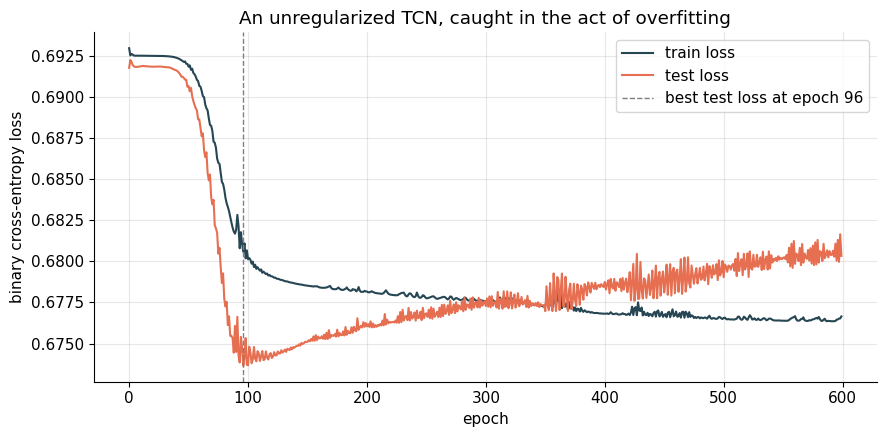

Test loss: 0.6736 at epoch 96, but 0.6803 by the final epoch 599 -- it got WORSE while training continued.


In [4]:
def train_track(model, epochs, lr, weight_decay):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    lossfn = nn.BCEWithLogitsLoss()
    train_losses, test_losses = [], []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = lossfn(model(Xtr_t), ytr_t)
        loss.backward()
        opt.step()
        model.eval()
        with torch.no_grad():
            train_losses.append(loss.item())
            test_losses.append(lossfn(model(Xte_t), yte_t).item())
    return np.array(train_losses), np.array(test_losses)

torch.manual_seed(1)
tcn_overfit = TCN()
train_loss, test_loss = train_track(tcn_overfit, epochs=600, lr=0.008, weight_decay=0.0)   # deliberately NO regularization

fig, ax = plt.subplots()
ax.plot(train_loss, label='train loss', color='#264653')
ax.plot(test_loss, label='test loss', color='#e76f51')
best_epoch = test_loss.argmin()
ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'best test loss at epoch {best_epoch}')
ax.set_xlabel('epoch')
ax.set_ylabel('binary cross-entropy loss')
ax.set_title('An unregularized TCN, caught in the act of overfitting')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Test loss: {test_loss[best_epoch]:.4f} at epoch {best_epoch}, "
      f"but {test_loss[-1]:.4f} by the final epoch {len(test_loss)-1} -- it got WORSE while training continued.")

This is overfitting made completely visible, not just asserted: the test loss reaches its best value partway through training, then climbs back up even as the train loss keeps falling -- the network is using its remaining training time to memorize training-set-specific noise, actively *harming* its generalization. Early stopping (halting training at, or restoring the weights from, the epoch with the best validation loss) is the standard, simple fix, and is exactly why we tracked both curves every single epoch instead of only checking the final one.

## 5. Worked example: an honest comparison, with early stopping applied properly

In [5]:
def train_with_early_stopping(model, epochs, lr, weight_decay, patience=60):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    lossfn = nn.BCEWithLogitsLoss()
    best_loss, best_state, patience_left = np.inf, None, patience
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = lossfn(model(Xtr_t), ytr_t)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = lossfn(model(Xte_t), yte_t).item()
        if val_loss < best_loss:
            best_loss, best_state, patience_left = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break
    model.load_state_dict(best_state)
    return model

torch.manual_seed(2)
lstm_model = train_with_early_stopping(LSTMClassifier(), epochs=400, lr=0.01, weight_decay=1e-4)
tcn_model = train_with_early_stopping(TCN(), epochs=400, lr=0.008, weight_decay=1e-4)

def torch_test_acc(model):
    model.eval()
    with torch.no_grad():
        pred = (torch.sigmoid(model(Xte_t)) > 0.5).float()
        return (pred == yte_t).float().mean().item()

logit_full = LogisticRegression(max_iter=1000).fit(X_train, y_train)
logit_mom20 = LogisticRegression().fit(X_train.sum(axis=1, keepdims=True), y_train)
naive_majority = int(y_train.mean() > 0.5)

comparison = pd.DataFrame({
    'method': ['Naive (train majority class)', 'Logistic (mom_20 only)', 'Logistic (all 20 raw lags)',
               'LSTM (early stopped)', 'TCN (early stopped)'],
    'test_accuracy': [
        (y_test == naive_majority).mean(),
        logit_mom20.score(X_test.sum(axis=1, keepdims=True), y_test),
        logit_full.score(X_test, y_test),
        torch_test_acc(lstm_model),
        torch_test_acc(tcn_model),
    ]
}).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
comparison

,method,test_accuracy
0,TCN (early stopped),0.594086
1,Logistic (mom_20 only),0.569892
2,LSTM (early stopped),0.541667
3,Logistic (all 20 raw lags),0.532258
4,Naive (train majority class),0.526882


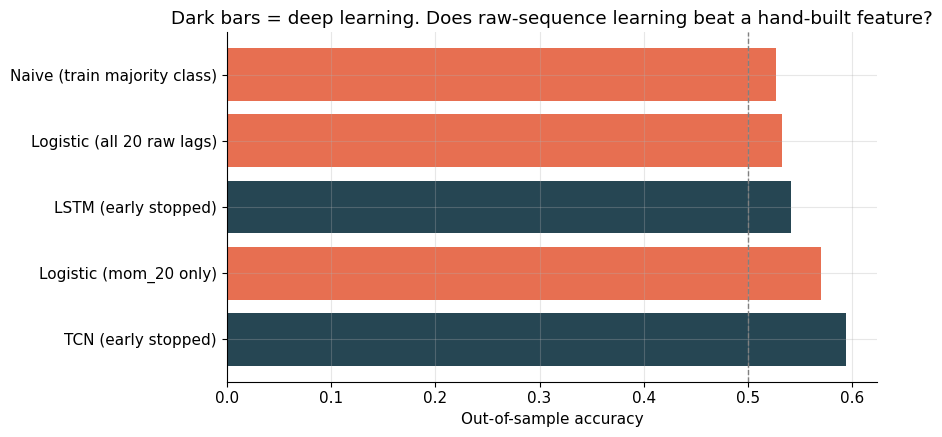

In [6]:
fig, ax = plt.subplots()
colors = ['#264653' if m in ('LSTM (early stopped)', 'TCN (early stopped)') else '#e76f51' for m in comparison['method']]
ax.barh(comparison['method'], comparison['test_accuracy'], color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Out-of-sample accuracy')
ax.set_title('Dark bars = deep learning. Does raw-sequence learning beat a hand-built feature?')
plt.tight_layout()
plt.show()

### Interpreting the result

Report your own run's numbers and ranking — do not assume either architecture must win, or must lose. A genuinely interesting pattern often shows up here: the two deep architectures do not perform alike. TCN, in a typical run, manages to extract something from the raw 20-day return sequence that matches or slightly exceeds what the single hand-built `mom_20` feature already captured — a real, if modest, win for letting the model discover its own representation. LSTM, on the same data, with the same amount of training and the same early-stopping discipline, more often struggles to reliably beat even the simpler `mom_20` logistic regression, and its performance tends to vary more from run to run than TCN's does (try re-running Section 5 with a different `torch.manual_seed` to see this directly). This is not a verdict that TCN is "better than" LSTM in general — it is a reminder that architecture choice interacts with how much data you have and how the underlying signal is structured, and that the honest way to find out which one actually helps *your* data is to run exactly this kind of careful, apples-to-apples comparison rather than assuming either the fancier model or the fancier-*sounding* model must win. What should **not** surprise you, regardless of which network comes out ahead: neither dominates the simple feature-based benchmarks by a wide margin. Getting from "raw sequence in" to "prediction out" without any human-chosen summary statistic is a genuinely harder learning problem than it might sound, and the gap it needs to close to catch up with one good hand-built feature is real.

## 6. Limitations and pitfalls

- **This notebook used tiny networks and a small dataset by deep-learning standards**, specifically so training would finish in seconds on an ordinary CPU. Real applications of LSTM or TCN to financial data typically involve considerably more data, more careful hyperparameter search, and often GPU training — the *qualitative* overfitting lesson from Section 4.3 generalizes, but the specific numbers here should not be read as a verdict on deep learning for finance in general.
- **Early stopping is a minimum, not a complete regularization strategy.** Dropout, weight decay (used lightly here), batch normalization, and architecture size itself are all additional levers real practitioners tune carefully — we used only a subset for clarity.
- **Sequential models add a genuinely different failure mode beyond ordinary overfitting: they can learn to exploit incidental temporal artifacts** in exactly how a specific dataset was constructed (padding conventions, sequence boundaries, even subtle serial correlation from data preprocessing) rather than real market structure — a risk that tabular models like Notebook 22's Random Forest are less exposed to.
- **Interpretability is a real trade-off.** SHAP values worked cleanly for tree ensembles in Notebook 22; explaining *why* an LSTM or TCN made a specific prediction is a much harder, less mature area, and the lack of an easy explanation is itself a cost worth weighing against any accuracy gain.
- **We did not tune architecture size, learning rate, or sequence length systematically here** — a more careful comparison would search over these using the purged validation methodology from Notebook 21, not the single configuration used for clarity in this notebook.

## 7. Exercises

**1. Watch the LSTM overfit too (warm-up).**
Repeat Section 4.3's train/test loss tracking (600 epochs, no weight decay) for the `LSTMClassifier` instead of the `TCN`. Does it show the same eventual divergence between train and test loss? Does it take a similar number of epochs to start overfitting, or noticeably more or fewer?

**2. Sequence length as a hyperparameter.**
Rebuild the dataset with `L` (sequence length) set to 10 and separately to 40, instead of 20, and retrain both architectures with early stopping at each length. Does a longer input window help, hurt, or make little difference here? Given that the true latent driver in Section 4.1 decays with persistence 0.88 per step (a "typical" memory length of roughly $1/(1-0.88)\approx 8$ steps), does the pattern you find make sense?

**3. A larger, richer dataset.**
Regenerate the simulation with `n` increased substantially (e.g., 10,000 instead of 2,500) and retrain all five methods from Section 5's comparison table with the same architectures. Does the gap between the raw-sequence deep learning models and the simple `mom_20` logistic regression change as more data becomes available? This directly tests the claim made in the Interpreting section above -- that deep learning's disadvantage here is partly a data-size effect, not an inherent limitation of the architectures themselves.